<a href="https://colab.research.google.com/github/kkeshavsharma/scratch_models/blob/main/LR_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**importing libraries**

In [19]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#**Dataset**

In [20]:
df = pd.read_csv("cleanhousing_).csv")

In [21]:
df = df.drop(["Unnamed: 0"], axis = 1)

#**Data Spliting**

In [22]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [23]:
df = df.sample(frac= 1, random_state = 42) #shuffle the data for random selection
ndf = df.drop("price", axis = 1)


In [24]:
len(df)

545

In [25]:
x_columns = ndf.columns

In [26]:
x_train = ndf.iloc[0 : len(ndf) // 100 * 80]
x_test = ndf.iloc[len(ndf) // 100 * 80 : ]

y_train = df["price"].iloc[0 : len(ndf) // 100 * 80 ]
y_test = df["price"].iloc[len(ndf) // 100 * 80 : ]

#**LR MODEL**

In [27]:
ndf.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')

####**train set**

In [28]:
 import random
 import math

#['''area'''8, '''bedrooms'''8, '''bathrooms'''4, '''stories'''4, '''mainroad'''4, '''guestroom'''2,
#      '''basement'''2,'''hotwaterheating'''1 , '''airconditioning'''6, '''parking'''4, '''prefarea'''7,
#     '''furnishingstatus'''5]

weight = [0,0,0,0,0,0,0,0,0,0,0,0]
bias = 0
for epoch in range(8000):
  # weight = np.zeros(x_train.shape[1])
  # weight = np.random.randn(x_train.shape[1]) * 0.01
  pred_y_train = np.dot(x_train, weight) + bias



  error = pred_y_train - y_train
  mse_sq = error ** 2
  if epoch % 1000 == 0:
    print(mse_sq.mean())

  learning_rate = 0.02
  weight = np.array(weight) - learning_rate * np.dot(x_train.T, error) / (len(x_train))
  bias = bias - learning_rate * error.sum() / len(error)
  if epoch % 1000 == 0:
    print(weight)
print("train set complete")




26303819248696.5
[819288.37328865 293195.266      136044.944      185839.913
  86897.9895      20665.75        36674.925        4877.25
  36440.397       81201.344       27762.5425      98877.394     ]
1203233854286.598
[ 137204.2117503    53364.67993611 1068600.7530751   501223.37193891
  493532.92942377  248189.77493628  247355.36181603  554937.12948081
 1009595.41184402  409004.82342852  919383.20238413  183292.87168196]
1181208637946.3076
[ 172887.37164213   55308.87712153 1082317.82282906  487179.87449405
  548638.15727979  223681.84668879  231131.51608099  841858.7855669
 1046157.89146827  391032.23866142  950020.00322605  175823.00882642]
1168043486758.4414
[ 212576.54661924   56343.97793002 1076912.37771577  486523.33682291
  551250.33220513  215827.22854921  231124.57029948  973586.26885268
 1054349.97146301  382887.3053074   952520.87663219  173896.80829311]
1157208936495.72
[ 251429.0772604    57292.88294256 1072657.83449949  487156.54651516
  546099.52115228  211108.1283122

In [29]:
pred_y_train = np.dot(x_train, weight) + bias
print(mse_sq.mean())

1122166616073.1868


In [30]:
error

,price
316,7.280510e+05
77,8.482384e+05
360,-6.538410e+05
90,-1.705871e+06
493,4.815676e+05
...,...
392,1.036261e+05
282,-1.172711e+05
358,1.880997e+05
397,2.341818e+05


In [31]:
print(pred_y_train[:10])
print(y_train[:10])

[4788065.26288862 7498243.27430311 3056155.80728429 4734130.7419177
 3281564.55162105 3146442.55151094 5339875.60032429 6364766.26513888
 2829541.75302143 2607203.83859587]
316    4060000
77     6650000
360    3710000
90     6440000
493    2800000
209    4900000
176    5250000
249    4543000
516    2450000
426    3353000
Name: price, dtype: int64


####**test set**

In [32]:
pred_y_test = np.dot(x_test, weight) + bias
print(pred_y_test.mean())

4664206.288458934


In [33]:
print(pred_y_test[:10])
print(y_test[:10])

[3278687.21366159 6278981.26714014 4491429.98103449 5337174.04795642
 6423331.9680128  5728469.57495107 2918204.5309457  4569680.40197802
 2936128.30604036 4777890.21329907]
469     3010000
4      11410000
256     4480000
509     2590000
100     6230000
226     4690000
508     2590000
213     4893000
479     2940000
171     5250000
Name: price, dtype: int64


#**R^2 error**

In [34]:
ss_tot = (y_test - y_test.mean()) ** 2
ss_tot_sum = ss_tot.sum()
ss_res = (y_test - pred_y_test) ** 2
ss_res_sum = ss_res.sum()
r_sqr = 1 - (ss_res_sum/ss_tot_sum)
r_sqr

np.float64(0.562933372228387)

Text(0.5, 0, 'actual price')

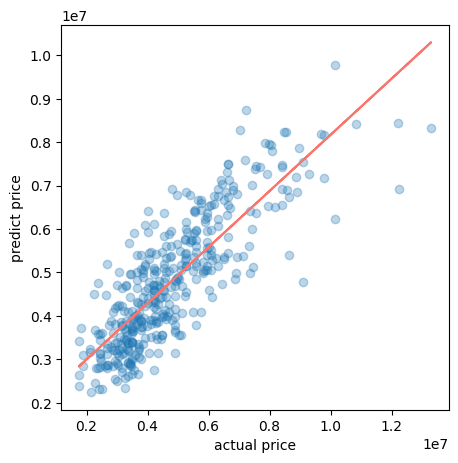

In [35]:
z=np.polyfit(y_train, pred_y_train, 1)
p = np.poly1d(z)


plt.figure(figsize=(5,5))
plt.scatter(x=y_train, y=pred_y_train, alpha = 0.3)
plt.plot(y_train, p(y_train), '#F8766D')
plt.ylabel('predict price')
plt.xlabel('actual price')